# **Распределение**
Для данного эксперемента я выбрал распределение Парето из библиотеки scipy.stats.
Особенность данного распределения в том, что оно описывает ситуации, где малая часть элементов обладает большой силой. у Парето «тяжелый хвост»: очень много маленьких значений и редкие, но экстремально большие значения.




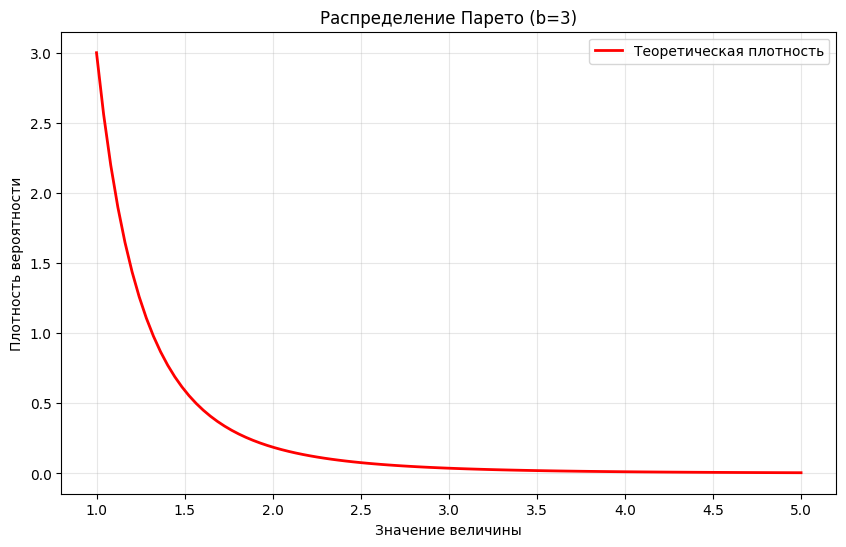

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd

b = 3 # параметр распределения Парето
size = 1000  # Сколько случайных чисел сгенерировать

data = stats.pareto.rvs(b, size=size)

plt.figure(figsize=(10, 6))
x = np.linspace(1, 5, 100)
pdf = stats.pareto.pdf(x, b)
plt.plot(x, pdf, 'r-', lw=2, label='Теоретическая плотность')

plt.title(f'Распределение Парето (b={b})')
plt.xlabel('Значение величины')
plt.ylabel('Плотность вероятности')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

# **Сходимость выборочного среднего к математическому ожиданию**

Как видно на графике, при увеличении размера выборки выборочное среднее всё меньше отклоняется от математического ожидания.

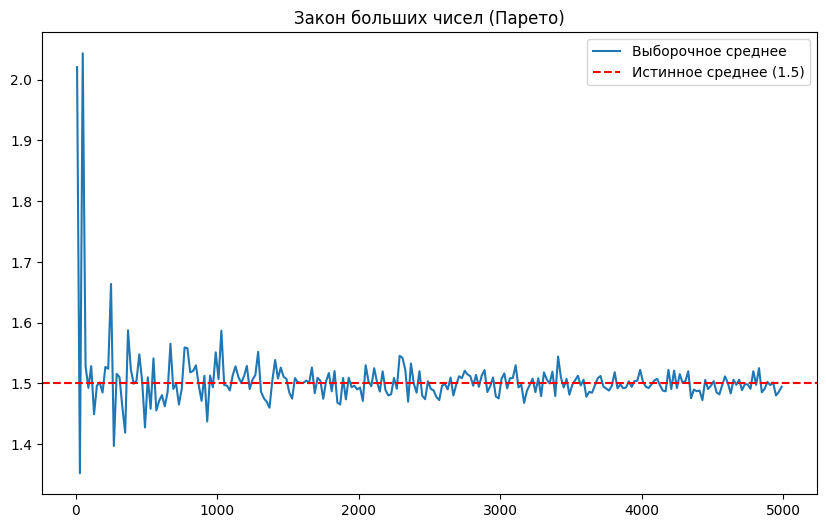

In [38]:
true_mean = b / (b - 1) # Истинное математическое ожидание для Парето: E[X] = b / (b - 1)

sizes = np.arange(10, 5000, 20)
means = [stats.pareto.rvs(b, size=s).mean() for s in sizes]

plt.figure(figsize=(10, 6))
plt.plot(sizes, means, label='Выборочное среднее')
plt.axhline(true_mean, color='red', linestyle='--', label=f'Истинное среднее ({true_mean})')
plt.title("Закон больших чисел (Парето)")
plt.legend()
plt.show()

# **Центральная предельная теорема**

На графиках видно, что при малых $n$ распределение выборочных средних сохраняет черты исходного распределения. Однако при увеличении объема выборки, согласно Центральной Предельной Теореме, форма гистограммы стабилизируется, становится симметричной и всё точнее описывается кривой нормального распределения с сужающейся стандартной ошибкой.

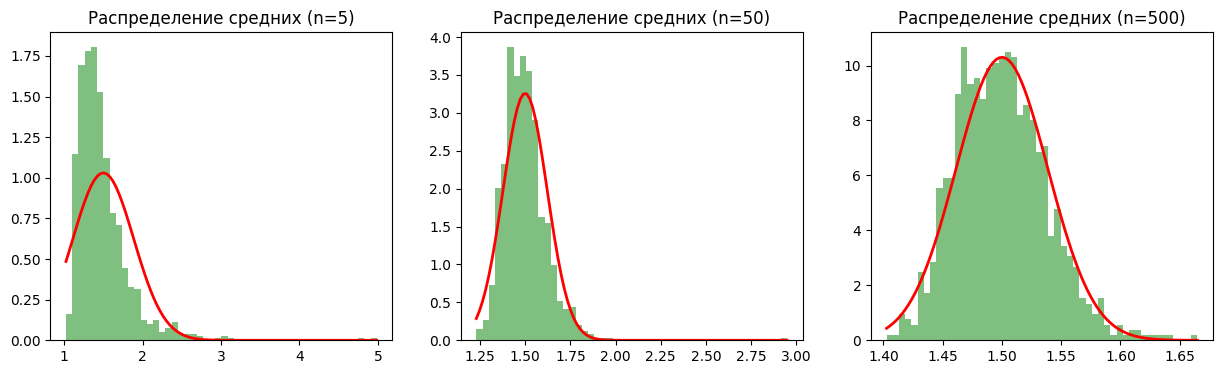

In [40]:
def plot_clt(n, n_simulations=1000):
    sample_means = [stats.pareto.rvs(b, size=n).mean() for _ in range(n_simulations)]
    plt.hist(sample_means, bins=50, density=True, alpha=0.5, color='green')

    mu = true_mean
    sigma_dist = np.sqrt((b) / ((b-1)**2 * (b-2))) # теоретическая дисперсия Парето
    se = sigma_dist / np.sqrt(n)

    x = np.linspace(min(sample_means), max(sample_means), 100)
    plt.plot(x, stats.norm.pdf(x, mu, se), 'r-', lw=2)
    plt.title(f"Распределение средних (n={n})")

plt.figure(figsize=(15, 4))
for i, n in enumerate([5, 50, 500]):
    plt.subplot(1, 3, i+1)
    plot_clt(n)
plt.show()

# **Асимптотический доверительный интервал для среднего значения на базе ЦПТ. Точный доверительный интервал для среднего значения (на базе t-критического значения). Эфронов доверительный интервал для среднего, медианы, моды, дисперсии.**

Наблюдается закономерное сужение всех типов ДИ при увеличении $n$, что говорит об уменьшении стандартной ошибки и росте точности оценки. Например, ширина точного ДИ уменьшилась почти в 12 раз при переходе от 10 к 1000 элементов. Это подтверждает закон, согласно которому ошибка уменьшается пропорционально $1/\sqrt{n}$.

Точный ДИ ожидаемо шире асимптотического на малых выборках ($n=10$), так как учитывает неопределенность оценки дисперсии. На больших выборках ($n=1000$) они практически идентичны.

Бутстрап (Эфронов ДИ) позволил получить интервальные оценки для медианы и дисперсии без использования аналитических формул. Для среднего значения результаты бутстрапа близки к классическим методам.

**Мода:** Интервал для моды, полученный методом Эфрона, крайне узок и локализован вблизи 1.0. Это объясняется тем, что у Парето максимальная плотность вероятности находится в самом начале распределения. Округление данных позволило бутстрапу корректно определить этот «пик».

**Дисперсия:** Доверительный интервал для дисперсии сильно асимметричен на малых $n$. Это характерная черта «тяжелых хвостов» Парето: случайное попадание одного большого числа в подвыборку резко увеличивает разброс, что бутстрап наглядно отразил.

**Медиана:** Доверительный интервал для медианы, полученный методом Эфрона, обычно уже, чем интервал для среднего значения. Это связано с природой распределения Парето: среднее значение сильно чувствительно к редким экстремально большим выбросам. Медиана же отсекает 50% выборки и игнорирует величину этих выбросов, поэтому её интервал получается более стабильным и компактным.

Таким образом, эксперимент подтвердил, что даже для асимметричных распределений статистические методы оценки среднего (ЦПТ) становятся чрезвычайно точными при росте выборки, а методы бутстрапа позволяют оценивать параметры (мода, медиана), для которых нет простых аналитических формул.

In [62]:
def get_full_analysis(n):
    sample = stats.pareto.rvs(b, size=n)

    mean = np.mean(sample)
    std_err = stats.sem(sample)

    # 1. Асимптотический ДИ (Z-критерий)
    z_crit = stats.norm.ppf(0.975)
    asymp_ci = (mean - z_crit * std_err, mean + z_crit * std_err)

    # 2. Точный ДИ (t-критерий)
    t_crit = stats.t.ppf(0.975, df=n-1)
    exact_ci = (mean - t_crit * std_err, mean + t_crit * std_err)

    # 3. Эфронов ДИ (Bootstrap)
    def bootstrap(data, func, n_boots=1000):
        boot_values = [func(np.random.choice(data, len(data))) for _ in range(n_boots)]
        return np.percentile(boot_values, [2.5, 97.5])

    boot_mean = bootstrap(sample, np.mean)
    boot_median = bootstrap(sample, np.median)
    boot_var = bootstrap(sample, np.var)
    boot_mode = bootstrap(sample, lambda x: stats.mode(np.round(x, 1), keepdims=True)[0][0])

    return {
        "Размер выборки (n)": n,
        "ДИ Асимпт. (Среднее)": np.round(asymp_ci, 2),
        "ДИ Точный (Среднее)": np.round(exact_ci, 2),
        "ДИ Эфронов (Среднее)": np.round(boot_mean, 2),
        "ДИ Эфронов (Медиана)": np.round(boot_median, 2),
        "ДИ Эфронов (Мода)": boot_mode,
        "ДИ Эфронов (Дисперсия)": np.round(boot_var, 2),
        "Ширина Асимпт. ДИ": round(asymp_ci[1] - asymp_ci[0], 3),
        "Ширина Точного ДИ": round(exact_ci[1] - exact_ci[0], 3),
        "Ширина Бутстрап ДИ (среднее)": round(boot_mean[1] - boot_mean[0], 3)
    }


sizes = [10, 100, 1000]
results = [get_full_analysis(n) for n in sizes]

df = pd.DataFrame(results)
print(df.to_string(index=False))

 Размер выборки (n) ДИ Асимпт. (Среднее) ДИ Точный (Среднее) ДИ Эфронов (Среднее) ДИ Эфронов (Медиана) ДИ Эфронов (Мода) ДИ Эфронов (Дисперсия)  Ширина Асимпт. ДИ  Ширина Точного ДИ  Ширина Бутстрап ДИ (среднее)
                 10         [0.96, 2.17]        [0.87, 2.26]         [1.15, 2.21]         [1.05, 1.52]        [1.0, 1.6]           [0.03, 2.04]              1.208              1.395                         1.051
                100         [1.39, 1.82]        [1.39, 1.82]         [1.43, 1.83]         [1.18, 1.38]        [1.0, 1.1]           [0.26, 2.54]              0.422              0.427                         0.401
               1000          [1.48, 1.6]         [1.48, 1.6]          [1.48, 1.6]         [1.23, 1.29]        [1.1, 1.1]           [0.59, 1.42]              0.121              0.121                         0.114
